# Chord to Chord Markov Model

This is an implementation of a markov model that predicts the next chord given
the previous chord. We decided to normalize all songs to C Major because this
reduces the space we need to deal with. Chord transitions don't depend on the
key that the song is in.

From midi_parser.ipynb this function receives a sequence of lettered chords
sampled every quarter note of the input song.

Plan:
```
Initialize chords (C, C#, D, D#, E, F, F#, G, G#, A, A#, B)^2 transition matrix. 

loop through every song in the dataset:
    for that song, midi_parse it to get chord array for song ('Dm', 'GM', 'CM')
        loop through every chord in the song from the second chord to the final
        chord. 
            Count transitions: Add a 1 to transition matrix for every chord
            transition.
Normalize the matrix so every column adds up to 1.
```
    

## Create a dataset of chords for each song. 

Takes about 10 mins to run 1400 songs.

In [1]:
import numpy as np
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob

#move to home directory
os.chdir('..')

In [2]:
def csv_to_tracks(file_path):
    """
    Reads a 4-column CSV and returns four 1D numpy arrays.
    
    Args:
        file_path (str): Path to the .csv file.
        
    Returns:
        tuple: (S, A, T, B) as 1D numpy arrays.
    """
    # unpack=True turns columns into individual arrays
    # skip_header=1 ignores the first row of text
    # delimiter=',' ensures we parse CSV format correctly
    S, A, T, B = np.genfromtxt(
        file_path, 
        delimiter=',', 
        unpack=True, 
        skip_header=1
    )
    
    return S, A, T, B


path = os.path.join('jsb_chorales', 'train', 'chorale_000.csv')
S, A, T, B = csv_to_tracks(path)

In [ ]:
def train_bass_to_bass_markov(dataset_dir):
    """
    arguments: a string with containing the training directory
    returns: a normalized B -> B markov transition matrix
    """
    songs = glob.glob('*.csv', root_dir=dataset_dir)
    songs = [s for s in songs if not 'd' in s] #remove all strings with 'd' in them (filters out chord csv)

    #can can shrink because they don't have access to all notes, just going to make a 128x128 mat
    counts = np.zeros((128, 128), dtype='int64')

    for song in tqdm(songs, desc="Parsing CSVs", unit="song"):
        song_path = os.path.join(dataset_dir, song)

        if os.path.exists(song_path):
            try:
                _, _, _, B = csv_to_tracks(song_path)

            except Exception as e:
                tqdm.write(f"Error processing {song_path}: {e}")

            N = len(B) #how many datapoints we have

            for i in range(1, N):
                #if B[i-1] != B[i]:
                    counts[int(B[i-1]), int(B[i])] += 1
            
    transition_matrix = counts / np.sum(counts) #normalize
    return transition_matrix

['chorale_198.csv', 'chorale_173.csv', 'chorale_167.csv', 'chorale_007.csv', 'chorale_013.csv', 'chorale_205.csv', 'chorale_211.csv', 'chorale_210.csv', 'chorale_204.csv', 'chorale_012.csv', 'chorale_006.csv', 'chorale_166.csv', 'chorale_172.csv', 'chorale_199.csv', 'chorale_158.csv', 'chorale_164.csv', 'chorale_170.csv', 'chorale_038.csv', 'chorale_010.csv', 'chorale_004.csv', 'chorale_212.csv', 'chorale_206.csv', 'chorale_207.csv', 'chorale_213.csv', 'chorale_005.csv', 'chorale_011.csv', 'chorale_039.csv', 'chorale_171.csv', 'chorale_165.csv', 'chorale_159.csv', 'chorale_161.csv', 'chorale_175.csv', 'chorale_149.csv', 'chorale_015.csv', 'chorale_001.csv', 'chorale_029.csv', 'chorale_217.csv', 'chorale_203.csv', 'chorale_202.csv', 'chorale_216.csv', 'chorale_028.csv', 'chorale_000.csv', 'chorale_014.csv', 'chorale_148.csv', 'chorale_174.csv', 'chorale_160.csv', 'chorale_189.csv', 'chorale_176.csv', 'chorale_162.csv', 'chorale_002.csv', 'chorale_016.csv', 'chorale_200.csv', 'chorale_21

Parsing CSVs: 100%|██████████| 229/229 [00:00<00:00, 1556.97song/s]


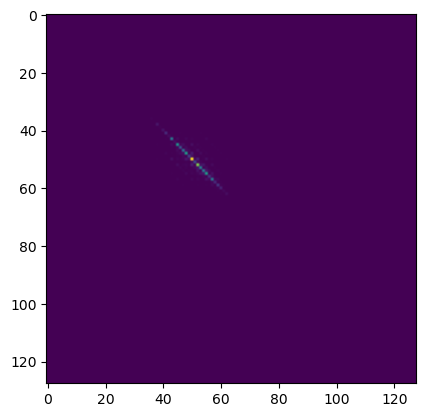

In [10]:
transition_matrix = train_bass_to_bass_markov(os.path.join('jsb_chorales', 'train'))
plt.imshow(transition_matrix)

In [ ]:
S, A, T, B = csv_to_tracks(os.path.join('jsb_chorales', 'train', 'chorale_000.csv'))

SATB_tuples = list(zip(S, A, T, B))
s, a, t, b = SATB_tuples[0]

In [ ]:
print(s,a,t,b)

74.0 70.0 65.0 58.0
